In [2]:
import os
import pandas as pd
import numpy as np
import sys
import re
import logging
from Modules.Loader_wrangler import *
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import matplotlib.pyplot as plt

In [3]:
# Configure basic logging
logging.basicConfig(level=logging.INFO, force=True, format='%(levelname)s: %(message)s')

In [ ]:
df2017 = loader(output_file_name="merged_df2017.pkl", chunksize=100000, sample_size=100000, survey_year=2017)
df2018 = loader(output_file_name="merged_df2018.pkl", chunksize=100000, sample_size=100000, survey_year=2018)
df2019 = loader(output_file_name="merged_df2019.pkl", chunksize=100000, sample_size=100000, survey_year=2019)
df2020 = loader(output_file_name="merged_df2020.pkl", chunksize=100000, sample_size=100000, survey_year=2020)
df2021 = loader(output_file_name="merged_df2021.pkl", chunksize=100000, sample_size=100000, survey_year=2021)

In [4]:
nts2017 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2017.pkl")
nts2018 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2018.pkl")
nts2019 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2019.pkl")
nts2020 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2020.pkl")
nts2021 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2021.pkl")

In [5]:
nts2017["IsTrip"] = 1
nts2018["IsTrip"] = 1
nts2019["IsTrip"] = 1
nts2020["IsTrip"] = 1
nts2021["IsTrip"] = 1

### Obtaining only relevant variables and making into a time series

## Data Manipulation pipeline

1. One-hot encode categorical features + any small cleaning steps
2. Add days of the week with no car travel
3. Make data frame into wide format
4. Convert to tensor

* Includes JourSeq gaps if trips were made by non-car inbetween

In [ ]:
### small cleaning steps and one hot encoding

In [19]:
#temporal_vars = ["TWSMonth", "TravelYear", "TravelWeekDay_B01ID"]
#individual_vars =["PSUGOR_B02ID", "IndIncome2002_B02ID", "HHoldNumChildren", "DVLALengthBand_B01ID"]

numerical_outcome_vars = ["TripStart", "TripEnd", "TripDisExSW"]
categorical_outcome_vars = ["TripPurpose_B01ID", "IsTrip"]

extra_vars = ["IndividualID_x", "JourSeq"]
features_one_hot = ["PSUGOR_B02ID"]


features_numerical = ["TravelYear", "ParkWk_B01ID", "OftHome_B01ID", "WkLift_B01ID", 'IndWkGOR_B02ID',
                     "EcoStat_B02ID", "PossHmN_B01ID", 'PDrivSt_B01ID',
                     "HHoldNumChildren", "IndIncome2002_B02ID", "DVLALengthBand_B01ID", 
                     'Age_B01ID', 
                     "DTJbLong_B01ID",
                    "DTJbMonth_B01ID",  
                    "EducN_B01ID",	
                    "HHoldEmploy_B01ID",	
                    "HHoldNumPeople",
                    "HHoldStruct_B02ID",	
                    "HRPWorkStat_B02ID",	
                    "WkMode_B01ID",	   
                    "WkPlace_B01ID"]
features_cyclical = ["TWSMonth", "TravelWeekDay_B01ID"]

features = features_one_hot + features_numerical + features_cyclical
outcomes = numerical_outcome_vars + categorical_outcome_vars

In [7]:
# Cyclical encoder

def apply_cyclical_encoding(column, type_, max_val):

    if type_ == "cos":
        return np.cos(2 * np.pi * column/ max_val)
    else:
        return np.sin(2 * np.pi * column/ max_val)


def custom_numerical_scaler(x, x_min, x_max, inverse=False):
    if not inverse:
        x_scaled = (x-x_min)/(x_max - x_min)
        return x_scaled
    else:
        x_unscaled = x*(x_max - x_min) + x_min
        return x_unscaled


standard_mms = MinMaxScaler()

def log_transformer(x, inverse=False):
    if not inverse:
        return np.log1p(x)
    else:
        return np.expm1(x)
    
# Apply one-hot to categorical
ohe = OneHotEncoder(sparse_output=False)

In [20]:
missing_mapping ={
    -8: 0,
    -9: 0,
    -10: 0,
}

for k, df in {2017: nts2017, 2018: nts2018, 2019: nts2019, 2020: nts2020, 2021: nts2021}.items():
    for feature in features:
        if feature not in df.columns:
            print(f"{k}: {feature}")

            # Appending feature with na
            df[feature] = 0


ts_df2017 = nts2017[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2018 = nts2018[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2019 = nts2019[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2020 = nts2020[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2021 = nts2021[features + outcomes + extra_vars].replace(missing_mapping)

ts_df_full = pd.concat([ts_df2017, ts_df2018, ts_df2019, ts_df2020, ts_df2021])

ts_df_full = pd.concat([ts_df2017, ts_df2018, ts_df2019, ts_df2020, ts_df2021])

df_to_transform = ts_df2017.copy()

# Apply cyclical encoding to cyclical column, assuming the same categories that appear in 2017 appear elsewhere

standard_mms.fit_transform(df_to_transform[features_numerical])
ohe.fit_transform(df_to_transform[features_one_hot])

# Careful not to run twice

for col in features_one_hot:
    df_to_transform[col] = df_to_transform[col].astype(int)

df_to_transform.loc[:, "TravelWeekDay_B01ID"] = df_to_transform.loc[:, "TravelWeekDay_B01ID"].astype(int)

### Imputing missing travel days

In [21]:
def impute_missing_travel_week_for_i(i_df, i_id, full_week_encoding, features=features, outcomes=outcomes):
        
    break_flag = False

    # Travel days with travel 
    included_travel_day = i_df["TravelWeekDay_B01ID"].to_list()

    # Travel days with no travel
    travel_day_no_drive = list(set(full_week_encoding) - set(included_travel_day))

    # These values will repeat for empty-travel travel days
    imputed_travel_df = pd.DataFrame({
        "TravelWeekDay_B01ID": travel_day_no_drive,
        "IndividualID_x": [i_id]*len(travel_day_no_drive),
        "JourSeq": [1]*len(travel_day_no_drive)
    })


    
    # Looping through all the columns in the original df
    for col in i_df.columns:

        # For days with no travel all outcomes vars will take 0
        if col in outcomes:
            imputed_travel_df[col] = [0]*len(travel_day_no_drive)

    
        else:
        
            if col not in extra_vars + ["TravelWeekDay_B01ID"]:
                if len(i_df[col].unique()) != 1:
                    print(f"{col} is erroneous for {i_id}")
                    print(f"Unique vals: {i_df[col].unique()}")
                    break_flag = True
                    break
                else:
                    imputed_travel_df[col] = i_df[col].unique()[0]

    if break_flag:
        print("Continuing to next individual")
        return
    

    #display(imputed_travel_df)
    #display(i_df)

    # Merging on IndividualID_x and TravelWeekDay_B01ID
    #full_df = i_df.merge(imputed_travel_df, on=["IndividualID_x", "TravelWeekDay_B01ID"], how="left")

    # Concatenating df to include empty travel days
    full_df = pd.concat([i_df, imputed_travel_df])
    #display(full_df)

    full_df = full_df.sort_values(["TravelYear", "TWSMonth", "TravelWeekDay_B01ID", "JourSeq", "TripStart", "TripEnd"])

    full_df.loc[:, "TWSMonth_cos"] = apply_cyclical_encoding(column=full_df["TWSMonth"], type_="cos", max_val=12)
    full_df.loc[:, "TWSMonth_sin"] = apply_cyclical_encoding(column=full_df["TWSMonth"], type_="sin", max_val=12)

    full_df.loc[:, "TravelWeekDay_B01ID_cos"] = apply_cyclical_encoding(column=full_df["TravelWeekDay_B01ID"], type_="cos", max_val=7)
    full_df.loc[:, "TravelWeekDay_B01ID_sin"] = apply_cyclical_encoding(column=full_df["TravelWeekDay_B01ID"], type_="sin", max_val=7)

    if full_df["TripStart"].max() > 1.5:
        full_df.loc[:,"TripStart"] = full_df["TripStart"].apply(lambda x: custom_numerical_scaler(x, x_max=60*24, x_min=0))

    if full_df["TripEnd"].max() > 1.5:
        full_df.loc[:,"TripEnd"] = full_df["TripEnd"].apply(lambda x: custom_numerical_scaler(x, x_max=60*24, x_min=0))

    full_df.loc[:,"TripDisExSW"] = full_df.loc[:,"TripDisExSW"].apply(lambda x: log_transformer(x))

    full_df.loc[:,features_numerical] = standard_mms.transform(full_df[features_numerical])

    ohe_array = ohe.transform(full_df[features_one_hot])
    ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(features_one_hot))

    # Reset index to avoid misalignment
    full_df.reset_index(drop=True, inplace=True)
    ohe_df.reset_index(drop=True, inplace=True)

    full_df = pd.concat([full_df, ohe_df], axis=1)

    #display(full_df)


    return full_df

### Transforming to wide

In [22]:
def transform_to_wide_for_i(i_df, max_journey_seq, seq_length = 7, outcomes=outcomes, features=features, extra_vars=extra_vars):
    df = i_df.copy()

    # Making column names based off all outcome categories

    TS_TE = []
    # TripStart TripEnd
    for TS,TE in zip(["TripStart"], ["TripEnd"]):
        for i in range(1, max_journey_seq+1):
            TS_TE.append(f"{TS}_{i}")
            TS_TE.append(f"{TE}_{i}")

    #print(TS_TE)

    expected_all = [f"{col}_{i}" for col in ["TripDisExSW", "TripPurpose_B01ID", "IsTrip"] for i in range(1, max_journey_seq+1)]

    expected_all = TS_TE + expected_all
    #print(expected_all)

    # Making column names for categorical outcomes only
    expected_categorical = [f"{col}_{i}" for col in categorical_outcome_vars for i in range(1, max_journey_seq+1)]

    # Applying max daily journeys cut off
    df = df[df["JourSeq"]<=max_journey_seq]

    # Transforming to wide
    df_wide = df.pivot(index="TravelWeekDay_B01ID",
                  columns = "JourSeq",
                  values = outcomes)
    
    df_wide.columns = [f"{col[0]}_{int(col[1])}" for col in df_wide.columns]

    for col in expected_all:
        if col not in df_wide.columns:
            df_wide[col] = 0
    
    # Ensure column order is consistent
    df_wide = df_wide[expected_all]
    
    df_wide = df_wide.fillna(0)

    df_wide.reset_index(inplace=True)

    # Dropping outcome columns
    df.drop(columns=outcomes + extra_vars, axis=1, inplace = True)
    df.drop_duplicates(subset=["TravelWeekDay_B01ID"], inplace=True)

    df_wide = df_wide.merge(df, on="TravelWeekDay_B01ID", how="left")

    top_row = df_wide.head(1).copy()

    for col in expected_all:
        top_row[col] = 0
        top_row["TravelWeekDay_B01ID"] = 0

    repeated_rows = pd.concat([top_row] * seq_length, ignore_index=True)

    df_wide = pd.concat([repeated_rows, df_wide], ignore_index=True)

    df_wide.drop(columns=features_one_hot + features_cyclical, inplace=True, axis=1)

    #df_wide.drop(columns=features_cyclical + features_one_hot, axis=1, inplace=True)

    targets_only = df_wide.drop(columns=features + extra_vars, axis=1, errors="ignore")

    targets_only = targets_only.iloc[seq_length:,:]

    targets_cont = targets_only[expected_all]
    targets_cont = targets_cont.copy()
    targets_cont.drop(columns=expected_categorical, axis=1, inplace=True)


    targets_cat = targets_only[expected_categorical]

    return df_wide, targets_cont, targets_cat

### Putting altogether for LSTM

In [23]:
def prepare_data_for_LSTM(long_df, impute_missing_travel_weeks=True, transform_to_wide=False, transform_to_tensor=False, debug=False):

    df = long_df.copy()
           

    #df = df[~df["DVLALengthBand_B01ID"].isin([-8, -10])]

    # All unique individual id's to loop over
    individual_ids = df["IndividualID_x"].unique()

    # Apply numerical encoding to numerical column
    #

    df_chunks = []

    full_week_encoding = list(range(1,8))

    if debug:
        random_index = random.randint(0, len(individual_ids))

        debug_df = df[df["IndividualID_x"] == individual_ids[random_index]]

        #display(debug_df)

        debug_df = impute_missing_travel_week_for_i(debug_df, i_id=individual_ids[random_index], full_week_encoding=full_week_encoding)

        #display(debug_df)

        debug_df, debug_targets_cont, debug_targets_cat = transform_to_wide_for_i(debug_df, max_journey_seq=10)

        
        for i, col in enumerate(debug_df.columns):
            print(f"{i}: {col}")
        print("")
        '''
        for i, col in enumerate(debug_targets_cont.columns):
            print(f"{i}: {col}")
        print("")
        for i, col in enumerate(debug_targets_cat.columns):
            print(f"{i}: {col}")'
        '''

        #print(debug_df.iloc[:,[0,1,2,3,20,31]].to_latex())

        #display(debug_df.iloc[0:7,[0,1,2,46]])

        display(debug_df)

        display(debug_targets_cont)

        display(debug_targets_cat)

        return
    
    if transform_to_tensor:
        individual_tensors = []
        target_cont_tensors = []
        target_cat_tensors = []
    
    if impute_missing_travel_weeks:

        for i, individual_id in enumerate(individual_ids[:]):

            i_df = df[df["IndividualID_x"] == individual_id]

            full_df = impute_missing_travel_week_for_i(i_df, i_id=individual_id, full_week_encoding=full_week_encoding)

            #display(full_df)

            if full_df is not None:
                if not transform_to_wide:
                    df_chunks.append(full_df)

                else:

                    full_df, targets_cont, targets_cat = transform_to_wide_for_i(full_df, max_journey_seq=10)

                    print(f"{full_df.shape}, {targets_cont.shape}, {targets_cat.shape}")
                    
                    if transform_to_tensor:

                        if full_df.shape[0] == 14 and targets_cont.shape[0] == 7 and targets_cat.shape[0] == 7:
                            full_arr = full_df.to_numpy()
                            full_arr = np.expand_dims(full_arr, axis=1)

                            targets_cont_arr = targets_cont.to_numpy()
                            targets_cat_arr = targets_cat.to_numpy()

                            full_i_tensor = torch.tensor(full_arr)
                            target_cont_i_tensor = torch.tensor(targets_cont_arr)
                            target_cat_i_tensor = torch.tensor(targets_cat_arr)

                            individual_tensors.append(full_i_tensor)
                            target_cont_tensors.append(target_cont_i_tensor)
                            target_cat_tensors.append(target_cat_i_tensor)


                    else:

                        #display(full_df)
                        print("")
                        #display(targets)
                        df_chunks.append(full_df)

            sys.stdout.write(f"\rIndividual {i+1} out of {len(individual_ids)} Complete!    ")
            sys.stdout.flush()

        if transform_to_tensor:
            individual_tensors = torch.stack(individual_tensors, dim=0)
            target_cont_tensors = torch.stack(target_cont_tensors, dim=0)
            target_cat_tensors = torch.stack(target_cat_tensors, dim=0)
            return individual_tensors, target_cont_tensors, target_cat_tensors
        
        else:

            df_to_return = pd.concat(df_chunks)

            return df_to_return



    else:
        return df


In [24]:
df = prepare_data_for_LSTM(long_df=ts_df2017, debug=True)


0: TripStart_1
1: TripEnd_1
2: TripStart_2
3: TripEnd_2
4: TripStart_3
5: TripEnd_3
6: TripStart_4
7: TripEnd_4
8: TripStart_5
9: TripEnd_5
10: TripStart_6
11: TripEnd_6
12: TripStart_7
13: TripEnd_7
14: TripStart_8
15: TripEnd_8
16: TripStart_9
17: TripEnd_9
18: TripStart_10
19: TripEnd_10
20: TripDisExSW_1
21: TripDisExSW_2
22: TripDisExSW_3
23: TripDisExSW_4
24: TripDisExSW_5
25: TripDisExSW_6
26: TripDisExSW_7
27: TripDisExSW_8
28: TripDisExSW_9
29: TripDisExSW_10
30: TripPurpose_B01ID_1
31: TripPurpose_B01ID_2
32: TripPurpose_B01ID_3
33: TripPurpose_B01ID_4
34: TripPurpose_B01ID_5
35: TripPurpose_B01ID_6
36: TripPurpose_B01ID_7
37: TripPurpose_B01ID_8
38: TripPurpose_B01ID_9
39: TripPurpose_B01ID_10
40: IsTrip_1
41: IsTrip_2
42: IsTrip_3
43: IsTrip_4
44: IsTrip_5
45: IsTrip_6
46: IsTrip_7
47: IsTrip_8
48: IsTrip_9
49: IsTrip_10
50: TravelYear
51: ParkWk_B01ID
52: OftHome_B01ID
53: WkLift_B01ID
54: IndWkGOR_B02ID
55: EcoStat_B02ID
56: PossHmN_B01ID
57: PDrivSt_B01ID
58: HHoldNumChi

,TripStart_1,TripEnd_1,TripStart_2,TripEnd_2,TripStart_3,TripEnd_3,TripStart_4,TripEnd_4,TripStart_5,TripEnd_5,...,TravelWeekDay_B01ID_sin,PSUGOR_B02ID_1.0,PSUGOR_B02ID_2.0,PSUGOR_B02ID_3.0,PSUGOR_B02ID_4.0,PSUGOR_B02ID_5.0,PSUGOR_B02ID_6.0,PSUGOR_B02ID_7.0,PSUGOR_B02ID_8.0,PSUGOR_B02ID_9.0
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.343750,0.352083,0.363194,0.375000,0.618056,0.626389,0.647917,0.652778,0.709722,0.713194,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8,0.343750,0.354167,0.368056,0.378472,0.395833,0.399306,0.618056,0.625000,0.638889,0.649306,...,9.749279e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9,0.347222,0.355556,0.364583,0.371528,0.381944,0.386111,0.440972,0.444444,0.000000,0.000000,...,4.338837e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


,TripStart_1,TripEnd_1,TripStart_2,TripEnd_2,TripStart_3,TripEnd_3,TripStart_4,TripEnd_4,TripStart_5,TripEnd_5,...,TripDisExSW_1,TripDisExSW_2,TripDisExSW_3,TripDisExSW_4,TripDisExSW_5,TripDisExSW_6,TripDisExSW_7,TripDisExSW_8,TripDisExSW_9,TripDisExSW_10
7,0.343750,0.352083,0.363194,0.375000,0.618056,0.626389,0.647917,0.652778,0.709722,0.713194,...,1.648659,1.648659,1.648659,1.098612,1.163151,0,0,0,0,0
8,0.343750,0.354167,0.368056,0.378472,0.395833,0.399306,0.618056,0.625000,0.638889,0.649306,...,1.648659,1.791759,0.693147,1.648659,1.648659,0,0,0,0,0
9,0.347222,0.355556,0.364583,0.371528,0.381944,0.386111,0.440972,0.444444,0.000000,0.000000,...,1.648659,1.648659,1.098612,1.098612,0.000000,0,0,0,0,0
10,0.347222,0.354167,0.364583,0.373611,0.618056,0.625000,0.638889,0.650000,0.000000,0.000000,...,1.648659,1.648659,1.648659,1.648659,0.000000,0,0,0,0,0
11,0.350694,0.361111,0.368056,0.376389,0.416667,0.430556,0.000000,0.000000,0.000000,0.000000,...,1.648659,1.029619,1.945910,0.000000,0.000000,0,0,0,0,0
12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0
13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0


,TripPurpose_B01ID_1,TripPurpose_B01ID_2,TripPurpose_B01ID_3,TripPurpose_B01ID_4,TripPurpose_B01ID_5,TripPurpose_B01ID_6,TripPurpose_B01ID_7,TripPurpose_B01ID_8,TripPurpose_B01ID_9,TripPurpose_B01ID_10,IsTrip_1,IsTrip_2,IsTrip_3,IsTrip_4,IsTrip_5,IsTrip_6,IsTrip_7,IsTrip_8,IsTrip_9,IsTrip_10
7,21.0,21.0,21.0,13.0,13.0,0,0,0,0,0,1.0,1.0,1.0,1.0,1.0,0,0,0,0,0
8,21.0,5.0,5.0,21.0,21.0,0,0,0,0,0,1.0,1.0,1.0,1.0,1.0,0,0,0,0,0
9,21.0,21.0,13.0,13.0,0.0,0,0,0,0,0,1.0,1.0,1.0,1.0,0.0,0,0,0,0,0
10,21.0,21.0,21.0,21.0,0.0,0,0,0,0,0,1.0,1.0,1.0,1.0,0.0,0,0,0,0,0
11,21.0,7.0,7.0,0.0,0.0,0,0,0,0,0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,0
12,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
13,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0


In [46]:
X, y_cont, y_cat = prepare_data_for_LSTM(long_df=ts_df2017, transform_to_wide=True, transform_to_tensor=True)

(14, 84), (7, 30), (7, 20)
Individual 1 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 2 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 3 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 4 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 5 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 6 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 7 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 8 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 9 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 10 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 11 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 12 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 13 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 14 out of 6838 Complete!    (14, 84), (7, 30), (7, 20)
Individual 15 out of 6838 Complete!    (14, 84), (7, 30), 

### Defining tensors and params

In [48]:
# Save tensors
with open("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/tensors/tensors.pkl", "wb") as f:
    pickle.dump((X, y_cont, y_cat), f)

In [49]:
#Load tensors
with open("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/tensors/tensors.pkl", "rb") as f:
    (X, y_cont_raw, y_cat_raw) = pickle.load(f)

In [50]:
# GPU?

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [51]:
X = X.to(torch.float32).to(device)

y_ts_te = y_cont_raw[:,:,:20].to(torch.float32).to(device)
y_distance = y_cont_raw[:,:,20:30].to(torch.float32).to(device)
y_purpouse = y_cat_raw[:,:,:10].to(torch.long).to(device)
y_istrip = y_cat_raw[:,:,10:].to(torch.float32).to(device)



index = 7
print(f"X: {X.shape}")
print(f"y_cont: {y_cont_raw.shape}")
print(f"y_cat: {y_cat_raw.shape}")
print(f"y_istrip: {y_istrip.shape}")
print(f"y_ts_et: {y_ts_te.shape}")
print(f"y_distance: {y_distance.shape}")
print(f"y_purpouse: {y_purpouse.shape}")
print(f"y_istrip: {y_istrip.shape}")

print(y_istrip[index,0,:])
print(y_purpouse[index,0,:])

X: torch.Size([6775, 14, 1, 84])
y_cont: torch.Size([6775, 7, 30])
y_cat: torch.Size([6775, 7, 20])
y_istrip: torch.Size([6775, 7, 10])
y_ts_et: torch.Size([6775, 7, 20])
y_distance: torch.Size([6775, 7, 10])
y_purpouse: torch.Size([6775, 7, 10])
y_istrip: torch.Size([6775, 7, 10])
tensor([1., 1., 1., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
tensor([ 1,  3, 23,  0,  0,  0,  0,  0,  0,  0], device='cuda:0')


### Creating the RNN

In [52]:
# Defining parameters
INPUT_SIZE = 84     # Total number of features
HIDDEN_SIZE = 9
NUM_LAYERS = 2
OUTPUT_SIZE_TS_TE = 20    # Outsize of TripStart and TripEnd
OUTPUT_SIZE_DIST = 10     # Output Size of distance
OUTPUT_SIZE_CAT = 10 # 10 outcome vars
OUTPUT_SIZE_BIN = 10 # 10 binary vars vars

NUM_CLASSES = 24

normalised_mp_minute = log_transformer(1.1667)  # *normalised minute



In [53]:
normalised_mp_minute

0.7732052727305244

In [54]:
# Calculating probability weights for categorical

def return_categorical_weightings(array, num_cats = 24):
    unique_vals, counts = torch.unique(array, return_counts=True)

    print(f"Unique vals: {unique_vals}")
    print(f"And their counts... {counts}")

    # 17 is missing this refers to "short walk", not relevant for our data, but will be kept for reference

    ce_weighting = torch.zeros(num_cats, dtype=torch.float32)
    
    if num_cats == 24:
        ce_weighting[17] = 0

    for val, count in zip(unique_vals, counts):
        ce_weighting[int(val)] = 1/(count/counts.sum())

    # Apply log scaling to smooth extreme weight differences
    ce_weighting = torch.log1p(ce_weighting)  

    # Normalize the weights
    ce_weighting /= ce_weighting.sum()

    print("Final CE Weights:", ce_weighting)

    ce_weighting = ce_weighting.to(device)

    return ce_weighting

In [55]:
ce_weighting = return_categorical_weightings(y_purpouse[:,:,:])
print("")
binary_weightings = return_categorical_weightings(y_istrip[:,:,:], num_cats=2)

Unique vals: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 18,
        19, 20, 21, 22, 23], device='cuda:0')
And their counts... tensor([376648,  19734,   4722,   1699,    343,  10319,   9438,   2123,     39,
          6232,   9276,   2532,   1052,   6142,   1460,    857,   3863,     16,
          1969,    248,   6510,   2873,   6155], device='cuda:0')
Final CE Weights: tensor([0.0067, 0.0264, 0.0378, 0.0461, 0.0592, 0.0315, 0.0322, 0.0443, 0.0770,
        0.0356, 0.0324, 0.0429, 0.0500, 0.0357, 0.0474, 0.0517, 0.0394, 0.0000,
        0.0843, 0.0449, 0.0619, 0.0352, 0.0418, 0.0357])

Unique vals: tensor([0., 1.], device='cuda:0')
And their counts... tensor([376648,  97602], device='cuda:0')
Final CE Weights: tensor([0.3155, 0.6845])


In [56]:
class RNNmodel(nn.Module):
    def __init__(self):
        super().__init__()

        # Define RNN layer

        self.rnn = nn.RNN(INPUT_SIZE, HIDDEN_SIZE, num_layers=NUM_LAYERS)

        # Output layers

        self.output_ts_te = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_TS_TE)
        self.output_dist = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_DIST)
        self.output_cat = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_CAT*NUM_CLASSES)
        self.output_bin = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_BIN)

        self.T = 1.0  # Can be used to scale categorical logits - useful for class imbalance


    def forward(self, X):

        out, hh = self.rnn(X)
        #print(f"hh_shape: {hh.shape}")

        y_ts_te_pred = self.output_ts_te(out[-1]).reshape(1,1,OUTPUT_SIZE_TS_TE)
        y_dist_pred = self.output_dist(out[-1]).reshape(1,1,OUTPUT_SIZE_DIST)
        y_cat_pred = self.output_cat(out[-1]).reshape(OUTPUT_SIZE_CAT, NUM_CLASSES)
        y_bin_pred = self.output_bin(out[-1]).reshape(OUTPUT_SIZE_BIN)

        y_bin_pred = y_bin_pred.to(torch.float32)

        # Applying sgmoid to get the loss mask
        y_bin_hat_sgmoid = F.sigmoid(y_bin_pred)
        y_bin_hat_sgmoid = (y_bin_hat_sgmoid > 0.5).float()
        y_mask = y_bin_hat_sgmoid.unsqueeze(1)
        

        # Adding softplus to ensure monotonicity in start and end time
        y_ts_te_pred = torch.cumsum(   F.softplus(y_ts_te_pred), dim=2   )

        #y_ts_te_pred = torch.clamp(y_ts_te_pred, min=0, max=1)
        y_distance_pred = torch.clamp(y_dist_pred, min=0)
        


        return y_ts_te_pred, y_distance_pred, y_cat_pred, y_bin_pred, y_mask


In [57]:
model = RNNmodel()

for a,b in model.named_parameters():
    print(a,b.shape)

rnn.weight_ih_l0 torch.Size([9, 84])
rnn.weight_hh_l0 torch.Size([9, 9])
rnn.bias_ih_l0 torch.Size([9])
rnn.bias_hh_l0 torch.Size([9])
rnn.weight_ih_l1 torch.Size([9, 9])
rnn.weight_hh_l1 torch.Size([9, 9])
rnn.bias_ih_l1 torch.Size([9])
rnn.bias_hh_l1 torch.Size([9])
output_ts_te.weight torch.Size([20, 9])
output_ts_te.bias torch.Size([20])
output_dist.weight torch.Size([10, 9])
output_dist.bias torch.Size([10])
output_cat.weight torch.Size([240, 9])
output_cat.bias torch.Size([240])
output_bin.weight torch.Size([10, 9])
output_bin.bias torch.Size([10])


In [58]:
# Taking one test draw

rnn_model = RNNmodel().to(device)

X0 = X[0,:,0,:].unsqueeze(1).to(torch.float32)
print(f"X1 shape: {X0.shape}")
print("")

y_ts_te_pred_1, y_distance_pred_1, y_purpouse_pred_1, y_istrip_pred_1, y_mask_1 = rnn_model.forward(X0)
y_ts_te_true_1, y_distance_true_1, y_purpouse_true_1, y_istrip_true_1 = y_ts_te[0,0,:].reshape(1,1,-1), y_distance[0,0,:].reshape(1,1,-1), y_purpouse[0,0,:], y_istrip[0,0,:]


print(f"y_ts_te_pred: {y_ts_te_pred_1.shape}")
print(f"y_distance_pred: {y_distance_pred_1.shape}")
print(f"y_purpouse_pred: {y_purpouse_pred_1.shape}")
print(f"y_bin_pred: {y_istrip_pred_1.shape}")
print(f"y_mask: {y_mask_1.shape}")

print(f"y_ts_te_pred: {y_ts_te_pred_1}")
print(f"y_distance_pred: {y_distance_pred_1}")
#print(f"y_distance_pred: {y_distance_pred_1.shape}")
#print(f"y_purpouse_pred: {y_purpouse_pred_1.shape}")
#print(f"y_bin_pred: {y_istrip_pred_1.shape}")
#print(f"y_mask: {y_mask_1.shape}")
#print("")
print(f"y_ts_te_true: {y_ts_te_true_1.shape}")
print(f"y_distance_true: {y_distance_true_1.shape}")
print(f"y_purpouse_true: {y_purpouse_true_1.shape}")
print(f"y_bin_true: {y_istrip_true_1.shape}")
print(f"y_mask: {y_mask_1.shape}")
print(f"y_ts_te_true: {y_ts_te_true_1.shape}")
print(f"y_distance_true: {y_distance_true_1.shape}")
print(f"y_purpouse_true: {y_purpouse_true_1.shape}")
print(f"y_bin_true: {y_istrip_true_1.shape}")
print(f"y_mask: {y_mask_1.shape}")

loss_cat = nn.CrossEntropyLoss()  #(y_hat, y)
loss_cont = nn.MSELoss()
loss_bin = nn.BCEWithLogitsLoss()

print(f"Categorical loss: {loss_cat(y_purpouse_pred_1, y_purpouse_true_1)}")
print(f"Continous loss: {loss_cont(y_ts_te_pred_1, y_ts_te_true_1)}")
print(f"Binary loss: {loss_bin(y_istrip_pred_1, y_istrip_true_1)}")

print("")
#print(binary)
print("")
#print(y_purpouse_pred_1)
print("Min max penalties for ts_te")
#ts_te_penalty_below_0 = - (torch.clamp(y_ts_te_pred_1, max = 0).sum())
ts_te_penalty_above_1 = torch.clamp(y_ts_te_pred_1-1, min = 0).sum()
print(f">1: {ts_te_penalty_above_1}")
print(f"ts_te_delta matrix")
ts_te_delta = y_ts_te_pred_1[:,:,1::2] - y_ts_te_pred_1[:,:,0::2]
print(ts_te_delta)
max_distance = ts_te_delta * normalised_mp_minute
print("Applying max distance")
print(max_distance)
print("Max distance penalty")
max_distance_penalty = torch.clamp(y_distance_pred_1 - max_distance, min=0).sum()
min_distance_penalty = torch.clamp(-y_distance_pred_1, min=0).sum()


X1 shape: torch.Size([14, 1, 84])

y_ts_te_pred: torch.Size([1, 1, 20])
y_distance_pred: torch.Size([1, 1, 10])
y_purpouse_pred: torch.Size([10, 24])
y_bin_pred: torch.Size([10])
y_mask: torch.Size([10, 1])
y_ts_te_pred: tensor([[[ 0.7434,  1.3712,  1.9463,  2.4790,  3.1397,  3.5562,  4.1228,
           4.5258,  5.1711,  6.1504,  6.7022,  7.2102,  7.7171,  8.2782,
           9.1368,  9.8240, 10.6613, 12.1636, 13.1244, 13.7386]]],
       device='cuda:0', grad_fn=<CumsumBackward0>)
y_distance_pred: tensor([[[3.3769e-01, 3.2555e-01, 7.3519e-04, 1.1597e-01, 5.8065e-01,
          9.9663e-02, 0.0000e+00, 0.0000e+00, 9.9905e-01, 2.5944e-01]]],
       device='cuda:0', grad_fn=<ClampBackward1>)
y_ts_te_true: torch.Size([1, 1, 20])
y_distance_true: torch.Size([1, 1, 10])
y_purpouse_true: torch.Size([10])
y_bin_true: torch.Size([10])
y_mask: torch.Size([10, 1])
y_ts_te_true: torch.Size([1, 1, 20])
y_distance_true: torch.Size([1, 1, 10])
y_purpouse_true: torch.Size([10])
y_bin_true: torch.Size([10

INFO: epoch: 0 | individual: 1 | loss 1-ahead: 766.002686 | loss 7-ahead: 694.215332
INFO: Categorical loss 1-ahead: 0.49504852294921875 | Categorical loss 7-ahead: 0.4994373023509979
INFO: epoch: 0 | individual: 2 | loss 1-ahead: 716.932373 | loss 7-ahead: 660.399170
INFO: Categorical loss 1-ahead: 0.211045041680336 | Categorical loss 7-ahead: 0.2090989053249359
INFO: epoch: 0 | individual: 3 | loss 1-ahead: 725.446533 | loss 7-ahead: 633.328491
INFO: Categorical loss 1-ahead: 0.21509450674057007 | Categorical loss 7-ahead: 0.20971044898033142
INFO: epoch: 0 | individual: 4 | loss 1-ahead: 690.026611 | loss 7-ahead: 612.761169
INFO: Categorical loss 1-ahead: 0.20891927182674408 | Categorical loss 7-ahead: 0.20951911807060242
INFO: epoch: 0 | individual: 5 | loss 1-ahead: 714.183716 | loss 7-ahead: 577.397766
INFO: Categorical loss 1-ahead: 0.39897993206977844 | Categorical loss 7-ahead: 0.38032907247543335
INFO: epoch: 0 | individual: 6 | loss 1-ahead: 686.275330 | loss 7-ahead: 602.7

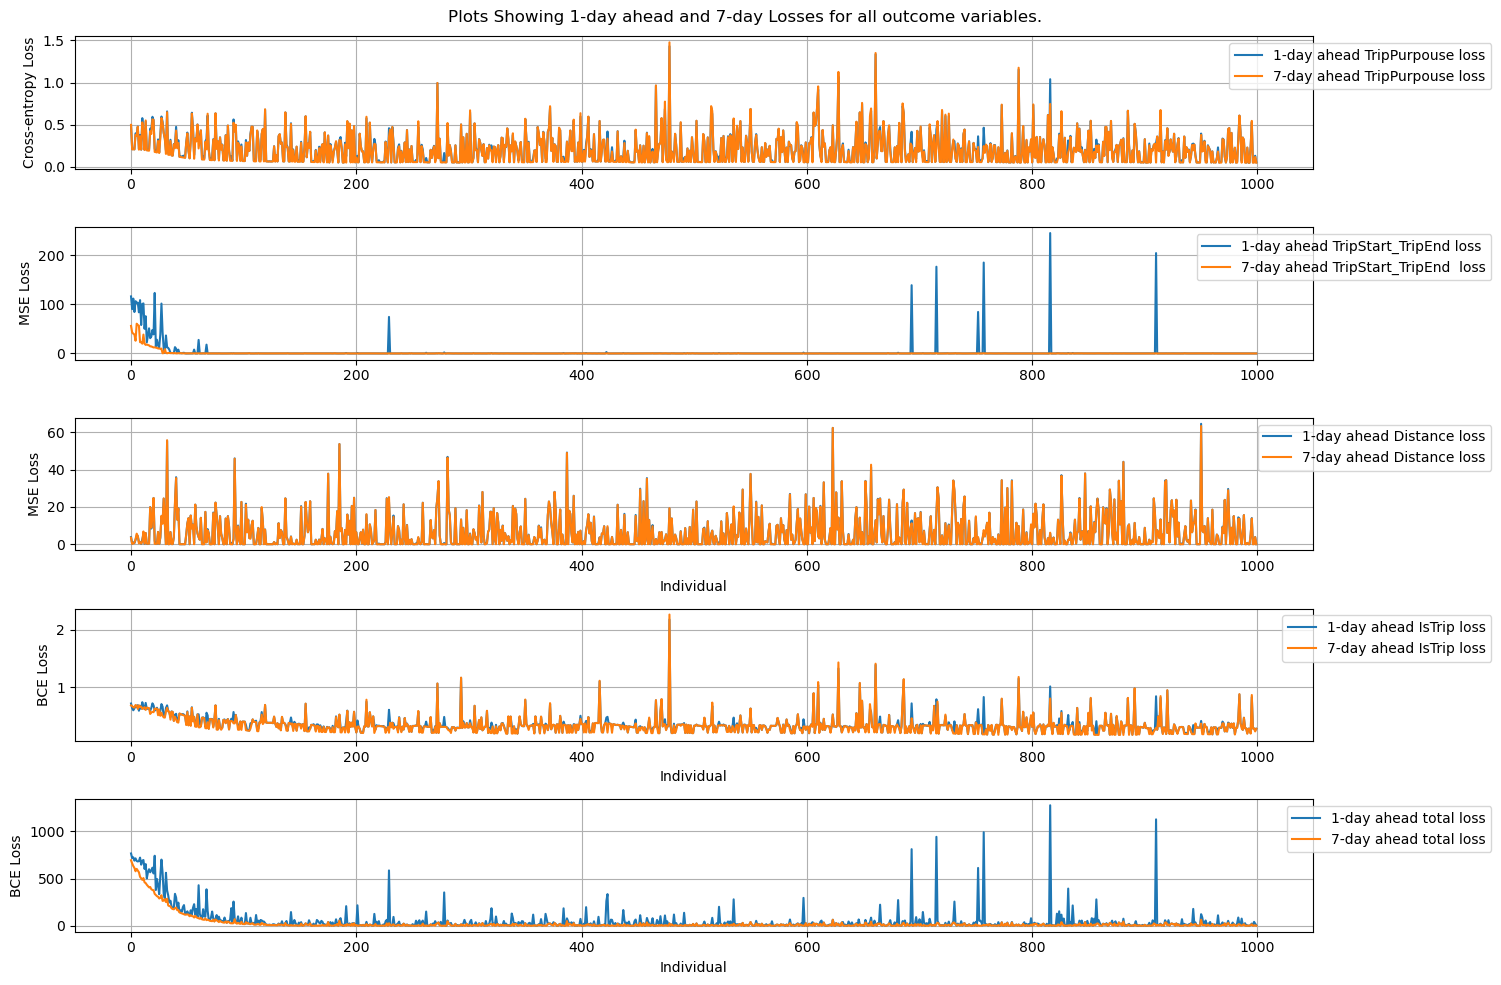

In [59]:
# Configure basic logging
logging.basicConfig(level=logging.INFO, force=True, format='%(levelname)s: %(message)s')


rnn_model = RNNmodel().to(device)

ce_loss = nn.CrossEntropyLoss(weight=ce_weighting, reduction="none").to(device)  #(y_hat, y)
mse_loss = nn.MSELoss(reduction="none").to(device)
bce_loss = nn.BCEWithLogitsLoss().to(device)

optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.0005)

epochs = 1
seq_length = 7
i_to_loop = 1000
last_x_i = 1

c1_penalty_weight = 5
c2_penalty_weight = 5

complete_travel_diaries = {}

for epochi in range(epochs):

    # Collecting losses
    purpouse_loss_for_i_1 = np.zeros(i_to_loop)
    purpouse_loss_for_i_7 = np.zeros(i_to_loop)
    
    ts_te_loss_for_i_1 = np.zeros(i_to_loop)
    #tripstart_loss_for_i_7 = np.zeros(i_to_loop)

    ts_te_loss_for_i_7 = np.zeros(i_to_loop)
    #tripend_loss_for_i_7 = np.zeros(i_to_loop)

    distance_loss_for_i_1 = np.zeros(i_to_loop)
    distance_loss_for_i_7 = np.zeros(i_to_loop)

    istrip_loss_for_i_1 = np.zeros(i_to_loop)
    istrip_loss_for_i_7 = np.zeros(i_to_loop)

    total_loss_1 = np.zeros(i_to_loop)
    total_loss_7 = np.zeros(i_to_loop)


    #print(epochi)
    for individual_i in range(i_to_loop):
        #print(f"Individual: {individual_i}")

        travel_diary = X[individual_i, :, 0, :].unsqueeze(1).to(torch.float32)
        logging.debug(travel_diary.shape)

        features = X[individual_i, :, 0, 50:].unsqueeze(1).to(torch.float32)

        travel_diary7 = X[individual_i, :7, 0, :].unsqueeze(1).to(torch.float32)

        logging.debug(f"Shape of travel diary: {travel_diary.shape}")

        for i in range(0, travel_diary.shape[0] - seq_length):

            # Conditions of violation

            logging.debug(f"Indexing travel diary from {i} until {seq_length+i}")


            

            sliding_input = travel_diary[i:seq_length+i,0,:].unsqueeze(1)
            logging.debug(f"Sliding input shape: {sliding_input.shape}")
            sliding_input7 = travel_diary7[i:seq_length+i,0,:].unsqueeze(1)


            #masked_outcome_rows = travel_diary[:7,0,:30].unsqueeze(1)
            #logging.debug(masked_outcome_rows.shape) 
            #feature_rows = travel_diary[:,0,30:].unsqueeze(1)
            #logging.debug(feature_rows.shape)

            #print(sliding_input.shape)

            ## 1-AHEAD PREDICTIONS ##

            y_ts_te_pred_1, y_distance_pred_1, y_purpouse_pred_1, y_istrip_pred_1, y_mask_1 = rnn_model.forward(sliding_input)
            
            categorical_prediction = torch.argmax(y_purpouse_pred_1, dim=-1)

            y_ts_te_true, y_distance_true, y_purpouse_true, y_istrip_true = y_ts_te[individual_i,i,:].reshape(1,1,-1), y_distance[individual_i,i,:].reshape(1,1,-1), y_purpouse[individual_i,i,:], y_istrip[individual_i,i,:]

            ## 7-AHEAD_PREDICTIONS ##

            y_ts_te_pred_7, y_distance_pred_7, y_purpouse_pred_7, y_istrip_pred_7, y_mask_7 = rnn_model.forward(sliding_input7)
            categorical_prediction7 = torch.argmax(y_purpouse_pred_7, dim=-1)

            logging.debug("Predictions pre transform")
            logging.debug(y_ts_te_pred_7.shape)
            logging.debug(y_distance_pred_7.shape)
            logging.debug(categorical_prediction7.shape)

            # Apending to traveldiary_7
            outcome_pred_7 = torch.cat([y_ts_te_pred_7.reshape(1,1,-1),  
                                        y_distance_pred_7.reshape(1,1,-1),
                                        categorical_prediction7.reshape(1,1,-1),
                                        y_istrip_pred_7.reshape(1,1,-1)], dim=-1).detach()
            
            logging.debug("Predictions post transform")
            logging.debug(outcome_pred_7.shape)
            
            features_7 = features[seq_length+i,:,:].unsqueeze(1)
            logging.debug(f"Features shape: {features_7.shape}")

            outcome_features_7 = torch.cat([outcome_pred_7, features_7], dim=-1)
            logging.debug(f"Outcome+features: {outcome_features_7.shape}")

            travel_diary7 = torch.cat([travel_diary7, outcome_features_7], dim=0)
            logging.debug(f"New travel diary7 shape: {travel_diary7.shape}")

            '''
            if individual_i > i_to_loop - last_x_i:             # Want to return a travel diary
                # What is the model predicting
                #logging.info("")
                logging.info("")
                sigmoided1 = F.sigmoid(y_istrip_pred_1)
                sigmoided7 = F.sigmoid(y_istrip_pred_7)
                binary1 = (sigmoided1 > 0.5).float()
                binary7 = (sigmoided7 > 0.5).float()
                logging.info(f"Istrip1: {binary7}")
                #logging.info(f"Istrip7: {binary7}")
                logging.info(f"IsTrip true: {y_istrip_true}")
                logging.info(f"y_tripstart_pred1: {y_ts_te_pred_7}")
                #logging.info(f"y_tripstart_pred7: {y_tripstart_pred_7}")
                #logging.info(f"y_tripend_pred7: {y_tripend_pred_7}")
                logging.info(f"y_distance_pred7: {y_distance_pred_7}")
                logging.info(f"Max Distance7: {max_distance7}")
                #logging.info(f"y_distance_pred7: {y_distance_pred_7}")
                logging.info(f"categorical ground truth: {y_purpouse_true}")
                logging.info(f"categorical prediction1: {categorical_prediction7}")
                logging.info("")
                #logging.info(f"Mask1: {y_mask_1}")
                #logging.info(f"Mask7: {y_mask_7}")
                #logging.info(f"Mask1_interleave: {y_mask_1.repeat_interleave(2)}")
                #logging.info(f"Mask7_interleave: {y_mask_7.repeat_interleave(2)}")
            '''

            if individual_i > i_to_loop - last_x_i:
                #logging.info("")
                #logging.info(y_distance_pred_7.reshape(1,1,-1).shape)
                #logging.info(categorical_prediction7.reshape(1,1,-1).shape)
                #logging.info(y_mask_7.shape)
                #logging.info((y_ts_te_pred_7 * y_mask_7.repeat_interleave(2)).reshape(1,1,-1).shape)
                #logging.info((y_distance_pred_7 * y_mask_7).reshape(1,1,-1).shape)
                #logging.info((categorical_prediction7 * y_mask_7).reshape(1,1,-1).shape)
                #logging.info(y_istrip_pred_7.reshape(1,1,-1).shape)



                outcome_pred_7_complete = torch.cat([ (y_ts_te_pred_7 * y_mask_7.repeat_interleave(2)).reshape(1,1,-1),  
                            (y_distance_pred_7 * y_mask_7.reshape(-1)        ).reshape(1,1,-1),
                            (categorical_prediction7 * y_mask_7.reshape(-1)     ).reshape(1,1,-1),
                            y_mask_7.reshape(1,1,-1)], dim=2).detach()
                
                logging.info(outcome_pred_7_complete.shape)
                
                if individual_i in complete_travel_diaries:
                    complete_travel_diaries[individual_i] = torch.cat([complete_travel_diaries[individual_i], outcome_pred_7_complete], dim=1).detach()
                else:
                    complete_travel_diaries[individual_i] = outcome_pred_7_complete


            # Compute MSE and CE loss for one-day-ahead of the week

            logging.debug(f"Original mask: {y_mask_1}")
            logging.debug(f"interleaved_mask: {y_mask_1.repeat_interleave(2)}")

            # RATIONALITY CONDITIONS

            ts_te_penalty_above_11 = torch.clamp(y_ts_te_pred_1-1, min = 0).sum()
            ts_te_penalty_above_17 = torch.clamp(y_ts_te_pred_7-1, min = 0).sum()

            ts_te_delta1 = y_ts_te_pred_1[:,:,1::2] - y_ts_te_pred_1[:,:,0::2]
            ts_te_delta7 = y_ts_te_pred_7[:,:,1::2] - y_ts_te_pred_7[:,:,0::2]

            max_distance1 = ts_te_delta1 * normalised_mp_minute
            max_distance7 = ts_te_delta7 * normalised_mp_minute

            max_distance_penalty1 = torch.clamp(y_distance_pred_1 - max_distance1, min=0).sum()
            min_distance_penalty1 = torch.clamp(-y_distance_pred_1, min=0).sum()
            total_distance_penalty1 = max_distance_penalty1 + max_distance_penalty1

            max_distance_penalty7 = torch.clamp(y_distance_pred_7 - max_distance7, min=0).sum()
            min_distance_penalty7 = torch.clamp(-y_distance_pred_7, min=0).sum()
            total_distance_penalty7 = max_distance_penalty7 + max_distance_penalty7

            ts_te_loss1 = mse_loss(y_ts_te_pred_1, y_ts_te_true)
            ts_te_loss1 = (ts_te_loss1 * y_mask_1.repeat_interleave(2)).sum() / (y_mask_1.repeat_interleave(2).sum() + 1e-6)

            #tripend_loss1 = mse_loss(y_tripend_pred_1, y_tripend_true)
            #tripend_loss1 = (tripend_loss1 * y_mask_1).sum() / (y_mask_1.sum() + 1e-6)

            distance_loss1 = mse_loss(y_distance_pred_1, y_distance_true)
            distance_loss1 = (distance_loss1 * y_mask_1).sum() / (y_mask_1.sum() + 1e-6)

            purpouse_loss1 = ce_loss(y_purpouse_pred_1, y_purpouse_true)
            purpouse_loss1 = (purpouse_loss1 * y_mask_1).sum() / (y_mask_1.sum() + 1e-6)

            istrip_loss1 = bce_loss(y_istrip_pred_1, y_istrip_true)

            logging.debug(f"y_istrip_pred_1 (logits): {y_istrip_pred_1}")
            logging.debug(f"y_istrip_true: {y_istrip_true}")
            logging.debug(f"BCE Loss: {istrip_loss1.item()}")

            combined_loss1 = ts_te_loss1 + distance_loss1 + purpouse_loss1 + istrip_loss1 + c1_penalty_weight*ts_te_penalty_above_11 + c2_penalty_weight*max_distance_penalty1

            # Compute MSE and CE loss for one-day-ahead of the week

            logging.debug("7-day ahead grads?")
            logging.debug(f"IsTrip: {y_istrip_pred_7.requires_grad}")
            logging.debug(f"y_tripstart_pred7: {y_ts_te_pred_7.requires_grad}")
            logging.debug(f"y_distance_pred7: {y_distance_pred_7.requires_grad}")
            logging.debug(f"y_purpouse_pred_7: {y_purpouse_pred_7.requires_grad}")

            ts_te_loss7 = mse_loss(y_ts_te_pred_7, y_ts_te_true)
            ts_te_loss7 = (ts_te_loss7 * y_mask_7.repeat_interleave(2)).sum() / (y_mask_7.repeat_interleave(2).sum() + 1e-6)

            distance_loss7 = mse_loss(y_distance_pred_7, y_distance_true)
            distance_loss7 = (distance_loss7 * y_mask_7).sum() / (y_mask_7.sum() + 1e-6)

            purpouse_loss7 = ce_loss(y_purpouse_pred_7, y_purpouse_true)
            purpouse_loss7 = (purpouse_loss7 * y_mask_7).sum() / (y_mask_7.sum() + 1e-6)

            istrip_loss7 = bce_loss(y_istrip_pred_7, y_istrip_true)

            combined_loss7 = ts_te_loss7 + distance_loss7 + purpouse_loss7 + istrip_loss7 + c1_penalty_weight*ts_te_penalty_above_17 + c2_penalty_weight*max_distance_penalty7

            optimizer.zero_grad()
            combined_loss7.backward()
            optimizer.step()

            #### WARNING - using the 7-day ahead loss to update weights won't work unless I fix up my computational graphs!
        # Checking gradients
        '''
        for name, param in rnn_model.named_parameters():
            if param.grad is not None:
                if "output_cat.weight" in name:
                    logging.info(f"{name} grad mean: {param.grad.mean().item():.6f}, std: {param.grad.std().item():.6f}")
        '''
            
        logging.info(f"epoch: {epochi} | individual: {individual_i+1} | loss 1-ahead: {combined_loss1:2f} | loss 7-ahead: {combined_loss7:2f}")
        logging.info(f"Categorical loss 1-ahead: {purpouse_loss1} | Categorical loss 7-ahead: {purpouse_loss7}")

        purpouse_loss_for_i_1[individual_i] = purpouse_loss1
        purpouse_loss_for_i_7[individual_i] = purpouse_loss7
        
        ts_te_loss_for_i_1[individual_i] = ts_te_loss1
        #tripstart_loss_for_i_7[individual_i] = tripstart_loss7

        ts_te_loss_for_i_7[individual_i] = ts_te_loss7
        #tripend_loss_for_i_7[individual_i] = tripstart_loss7

        distance_loss_for_i_1[individual_i] = distance_loss1
        distance_loss_for_i_7[individual_i] = distance_loss7

        istrip_loss_for_i_1[individual_i] = istrip_loss1
        istrip_loss_for_i_7[individual_i] = istrip_loss7

        total_loss_1[individual_i] = combined_loss1
        total_loss_7[individual_i] = combined_loss7

        


plt.figure(figsize=(15, 10))

plt.suptitle("Plots Showing 1-day ahead and 7-day Losses for all outcome variables.")

x_vals = np.arange(i_to_loop)  # Ensure correct x-axis scaling

# Plot 1: TripPurpose Loss
plt.subplot(5, 1, 1)
plt.plot(x_vals, purpouse_loss_for_i_1, label="1-day ahead TripPurpouse loss")
plt.plot(x_vals, purpouse_loss_for_i_7, label="7-day ahead TripPurpouse loss")
plt.ylabel("Cross-entropy Loss")
plt.grid()
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))

# Plot 2: 1-day MSE Losses
plt.subplot(5, 1, 2)
plt.plot(x_vals, ts_te_loss_for_i_1, label="1-day ahead TripStart_TripEnd loss")
plt.plot(x_vals, ts_te_loss_for_i_7, label="7-day ahead TripStart_TripEnd  loss")
plt.ylabel("MSE Loss")
plt.grid()
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


# Plot 3: 7-day MSE Losses
plt.subplot(5, 1, 3)
plt.plot(x_vals, distance_loss_for_i_1, label="1-day ahead Distance loss")
plt.plot(x_vals, distance_loss_for_i_7, label="7-day ahead Distance loss")
plt.xlabel("Individual")
plt.ylabel("MSE Loss")
plt.grid()
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))

# Plot 3: 7-day MSE Losses
plt.subplot(5, 1, 4)
plt.plot(x_vals, istrip_loss_for_i_1, label="1-day ahead IsTrip loss")
plt.plot(x_vals, istrip_loss_for_i_7, label="7-day ahead IsTrip loss")
plt.xlabel("Individual")
plt.ylabel("BCE Loss")
plt.grid()
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))

# Plot 3: 7-day MSE Losses
plt.subplot(5, 1, 5)
plt.plot(x_vals, total_loss_1, label="1-day ahead total loss")
plt.plot(x_vals, total_loss_7, label="7-day ahead total loss")
plt.xlabel("Individual")
plt.ylabel("BCE Loss")
plt.grid()
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))

plt.tight_layout()

# Save plot as PDF
plt.savefig("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/loss_plot.pdf", format="pdf", dpi=300, bbox_inches="tight")


plt.show()
    


In [61]:
df = pd.DataFrame(complete_travel_diaries[1000].reshape(7,50).cpu().numpy())
df.iloc[:,:20] = df.iloc[:,:20].apply(lambda x: custom_numerical_scaler(x=x, x_min=0, x_max=60*24, inverse=True))
df.iloc[:,20:30] = df.iloc[:,20:30].apply(lambda x: log_transformer(x, inverse=True))

df.iloc[:,:]

KeyError: 1000

,40,41,42,43,44,45,46,47,48,49
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
